Competition: besides trying to predict the success of drawings, we could also see 

how coalition sizes are impacted by competition. The hypothesis is that coalition sizes should increase with competition. 

We could compute the normalized distribution of coalition sizes (is percentage of the total number of users) and see how it varies over time. We could compare coalition sizes against subreddit popularity (where there is no competition).

In [14]:
import csv
import numpy as np
from analysis import *
import sys
#import basic libraries

import os
import math
import numpy.linalg as npla
import scipy
from scipy import sparse
from scipy import linalg
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt 
from matplotlib import cm
from scipy.fftpack import fft, fftfreq
from statsmodels.tsa.seasonal import seasonal_decompose

import matplotlib.mlab as mlab
from mpl_toolkits.mplot3d import axes3d
#%matplotlib tk
import operator
#import datashader as ds
#from datashader.mpl_ext import dsshow
import mpl_scatter_density
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mtick

# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '/home/yw180/place/analysis/Python_code/')
from project_data_analysis import pixels_per_project, Create_Array
import pickle
import powerlaw

start_time = 1490918688

In [3]:
with open("/scratch/yw180/reddit_thread/successful_col.pkl", "rb") as input_file:
    successful_dict = pickle.load(input_file)
with open("/scratch/yw180/reddit_thread/failed_col.pkl", "rb") as input_file:
    failed_dict = pickle.load(input_file)

In [4]:
input_tile_file = "/scratch/yw180/place/data/sorted_tile_placements.csv"

In [20]:
def make_update_user_time_dict(input_tile_file):
    update_user_dict = dict()
    with open(input_tile_file,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)
        for r in reader:
            t = int(int(r[1])/1000)
            up_num = int(r[0])
            user = r[2]
#             x = int(r[3])
#             y = int(r[4])
#             color = r[5]
            update_user_dict[up_num] = list([user,t])
    return update_user_dict

In [21]:
def make_update_coord_dict(input_tile_file):
    update_coord_dict = dict()
    with open(input_tile_file,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)
        for r in reader:
            up_num = int(r[0])
            x = int(r[3])
            y = int(r[4])
            update_coord_dict[up_num] = (x,y)
    return update_coord_dict

In [22]:
def total_user_over_time(input_file, start_time):
    out = dict()
    with open(input_tile_file,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)

        for line in reader:
            t = elapsed_time(start_time,int(int(line[1])/1000))
            user = line[2]
            if t not in out:
                out[t] = {user}
            else:
                out[t].add(user)
    prev_coalition = set()
    coalition_out = dict()
    k_list = sorted(out.keys())
    for key in k_list:
        prev_coalition = prev_coalition | out[key]
        coalition_out[key] = len(prev_coalition)
    return coalition_out

In [23]:
def make_update_proj_dict(succ_file, failed_file):
    update_proj_dict = dict()
    with open(succ_file,'r') as file:
        # Skip first line (header row)
        reader = csv.reader(file)
        line_count = 0
        for r in reader:   
            for update in r:
                update = int(update)
                update_proj_dict[update] = "s" + str(line_count)
                if update == 485:
                    print("485, succ", line_count)
            line_count += 1

    with open(failed_file,'r') as file:
        # Skip first line (header row)
        reader = csv.reader(file)
        line_count = 0
        for r in reader:   
            for update in r:
                update = int(update)
                update_proj_dict[update] = "f" + str(line_count)
                if update == 485:
                    print("485, failed", line_count)
            line_count += 1

    return update_proj_dict

In [24]:
def make_proj_size_dict(succ_file, failed_file):
    proj_size_dict = dict()
    with open(succ_file,'r') as file:
        # Skip first line (header row)
        reader = csv.reader(file)
        line_count = 0
        for r in reader:   
            proj_size_dict["s" + str(line_count)] = len(r)
            line_count += 1
    with open(failed_file,'r') as file:
        # Skip first line (header row)
        reader = csv.reader(file)
        line_count = 0
        for r in reader:   
            proj_size_dict["f" + str(line_count)] = len(r)
            line_count += 1
    return proj_size_dict

In [25]:
total_user_o_t = total_user_over_time(input_tile_file, start_time)

In [26]:
update_user_dict = make_update_user_time_dict(input_tile_file)

In [27]:
update_coord_dict = make_update_coord_dict(input_tile_file)

In [30]:
update_proj_dict = make_update_proj_dict(successful_dir,failed_dir)

In [31]:
proj_size_dict = make_proj_size_dict(successful_dir, failed_dir)

In [29]:
successful_dir = "/scratch/yw180/place/data/successful_4.csv"
failed_dir = "/scratch/yw180/place/data/unsuccessful_4.csv"

In [17]:
def elapsed_time(start_time, t):
    return int(math.floor((t - start_time)/3600))

def make_coalition_over_time(input_succ_file, pos, start_time, update_user_dict):
    counter = 0
    coalition_t_count = dict()
    with open(input_succ_file,'r') as file:
        # Skip first line (header row)
        reader = csv.reader(file)
        for r in reader:
            if counter != pos:
                counter += 1
                continue
            else:
                for update in r:
                    update = int(update)
                    elapsed_t = elapsed_time(start_time, int(update_user_dict[update][1]))
                    user = update_user_dict[update][0]
                    if elapsed_t not in coalition_t_count:
                        coalition_t_count[elapsed_t] = {user}
                    else:
                        coalition_t_count[elapsed_t].add(user)
                break
    total = 0
    coalition_out = dict()
#     for key in coalition_t_count:
#         coalition_out[key] = len(coalition_t_count[key])
#         total += len(coalition_t_count[key])
    prev_coalition = set()
    k_list = sorted(coalition_t_count.keys())
    for key in k_list:
        prev_coalition = prev_coalition | coalition_t_count[key]
        coalition_out[key] = len(prev_coalition)
    total += len(prev_coalition)
    return total, coalition_out

In [18]:
def elapsed_time(start_time, t):
    return int(math.floor((t - start_time)/3600))

def overall_coalition_over_time(input_succ_file, start_time, update_user_dict):
    counter = 0
    coalition_t_count = dict()
    with open(input_succ_file,'r') as file:
        # Skip first line (header row)
        reader = csv.reader(file)
        for r in reader:
            for update in r:
                update = int(update)
                elapsed_t = elapsed_time(start_time, int(update_user_dict[update][1]))
                user = update_user_dict[update][0]
                if elapsed_t not in coalition_t_count:
                    coalition_t_count[elapsed_t] = {user}
                else:
                    coalition_t_count[elapsed_t].add(user)
    total = 0
    coalition_out = dict()
#     for key in coalition_t_count:
#         coalition_out[key] = len(coalition_t_count[key])
#         total += len(coalition_t_count[key])
    prev_coalition = set()
    k_list = sorted(coalition_t_count.keys())
    for key in k_list:
        prev_coalition = prev_coalition | coalition_t_count[key]
        coalition_out[key] = len(prev_coalition)
    total += len(prev_coalition)
    return total, coalition_out

In [19]:
def plot_time_pos_neg(coalition_count,total_coalition, attack_count,img_loc,duration=89):
    fig = plt.figure(figsize=(12, 2))
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.15)
    ax = fig.add_subplot(gs[0, 0])
#     neg_x = np.arange(0, duration)
#     neg_y = np.zeros(duration)
#     total_attack = sum(attack_count.values())
#     for i in range(0, len(neg_x)):
#         if neg_x[i] in attack_count:
#             neg_y[i] = -(attack_count[neg_x[i]] / total_attack) * 100
    pos_x = np.arange(0, duration)
    pos_y = np.zeros(duration)
    for i in range(0, len(pos_x)):
        if pos_x[i] in coalition_count:
            pos_y[i] = (coalition_count[pos_x[i]] / total_coalition[i]) * 100
    ax.plot(pos_x, pos_y, 'b-')

    ax.fill_between(pos_x,0, pos_y, facecolor='#add8e6')

#     ax.plot(neg_x, neg_y, 'r-')
#     ax.fill_between(neg_x,0, neg_y, facecolor='#FFADB0')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_yticklabels("count (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
#     ax.set_yticks([])
    ax_image = fig.add_subplot(gs[0, 1])
    img = Image.open(img_loc)
    imgbox = OffsetImage(img, zoom=0.03)
    ab = AnnotationBbox(imgbox, (0, 0.5), frameon=False, box_alignment=(0.5, 0.5))
    ax_image.add_artist(ab)
    ax_image.axis('off') 

    # Adding labels and title
#     fig.text(0.37, 0.04, 'Hours', va='center',fontsize=15)
#     fig.text(0.1, 0.5, 'Collaborative vs. Adversarial Updates', va='center', rotation='vertical',fontsize=15)

    plt.show()

# Successful

In [161]:
total, coalition_count = make_coalition_over_time(successful_dir, 0, start_time, update_user_dict)

/tmp/ipykernel_2737304/961760666.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels("count (%)")


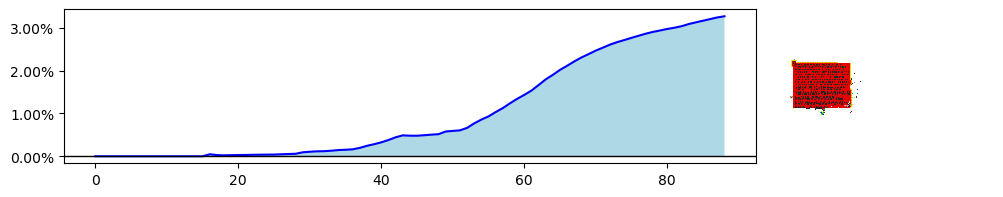

In [172]:
plot_time_pos_neg(coalition_count, total_user_o_t, successful_dict[0][1],"/home/yw180/place/place_graphcut_user_emb/Merged_analysis/plots/0.png")

In [173]:
total, coalition_count = make_coalition_over_time(successful_dir, 5, start_time, update_user_dict)

/tmp/ipykernel_2737304/961760666.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels("count (%)")


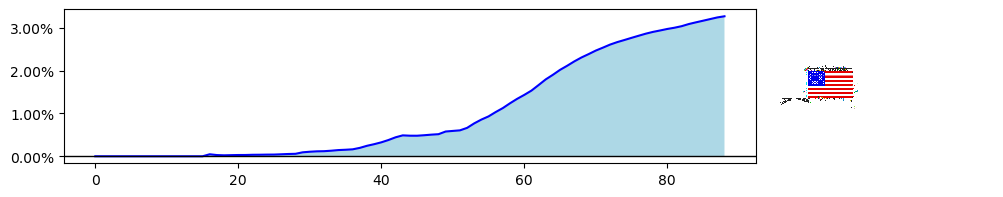

In [174]:
plot_time_pos_neg(coalition_count, total_user_o_t, successful_dict[5][1],"/home/yw180/place/place_graphcut_user_emb/Merged_analysis/plots/5.png")

In [175]:
total, coalition_count = make_coalition_over_time(successful_dir, 4, start_time, update_user_dict)

/tmp/ipykernel_2737304/961760666.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels("count (%)")


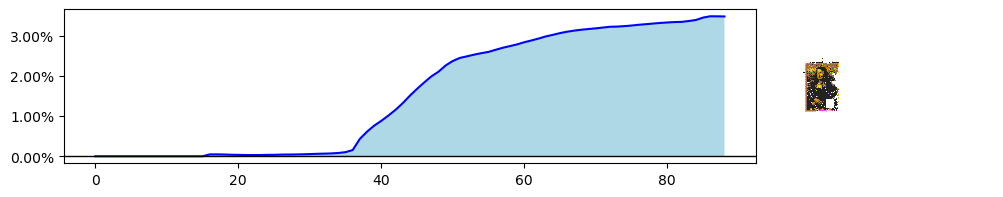

In [176]:
plot_time_pos_neg(coalition_count, total_user_o_t, successful_dict[4][1],"/home/yw180/place/place_graphcut_user_emb/Merged_analysis/plots/4.png")

# Failed

In [178]:
total, coalition_count = make_coalition_over_time(failed_dir, 0, start_time, update_user_dict)

/tmp/ipykernel_2737304/961760666.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels("count (%)")


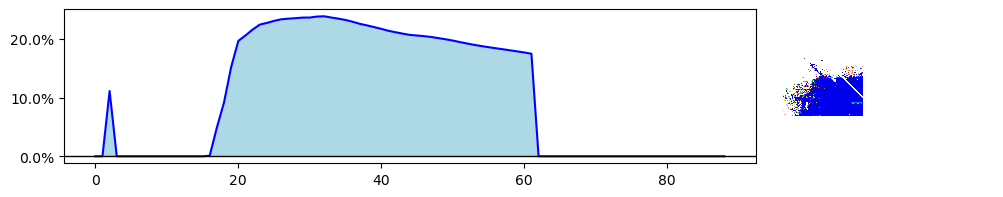

In [179]:
plot_time_pos_neg(coalition_count, total_user_o_t, failed_dict[0][1],"/home/yw180/place/place_graphcut_user_emb/Merged_analysis/plots/failed_0.png")

In [180]:
total, coalition_count = make_coalition_over_time(failed_dir, 1, start_time, update_user_dict)

/tmp/ipykernel_2737304/961760666.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels("count (%)")


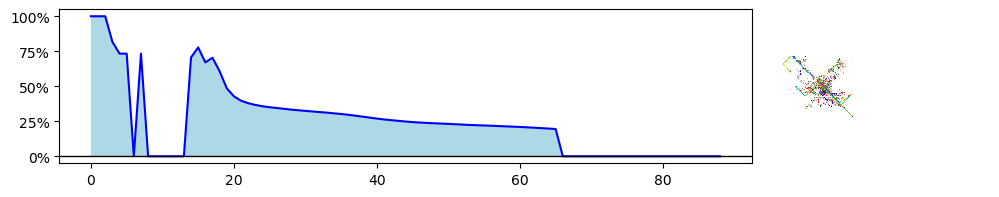

In [181]:
plot_time_pos_neg(coalition_count, total_user_o_t, failed_dict[1][1],"/home/yw180/place/place_graphcut_user_emb/Merged_analysis/plots/failed_1.png")

In [183]:
total_user_o_t[0]

4

In [184]:
total, coalition_count = make_coalition_over_time(failed_dir, 34, start_time, update_user_dict)

/tmp/ipykernel_2737304/961760666.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels("count (%)")


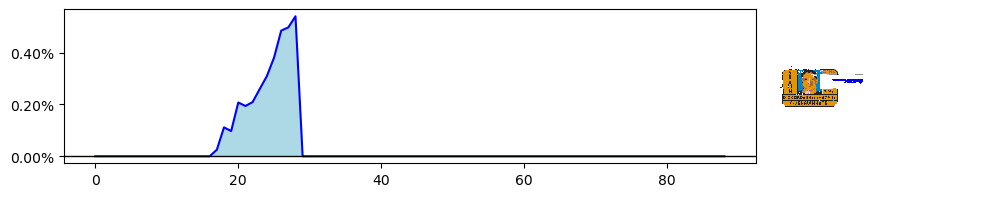

In [186]:
plot_time_pos_neg(coalition_count, total_user_o_t, failed_dict[8][1],"/home/yw180/place/place_graphcut_user_emb/Merged_analysis/plots/failed_8.png")

/tmp/ipykernel_2737304/961760666.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels("count (%)")


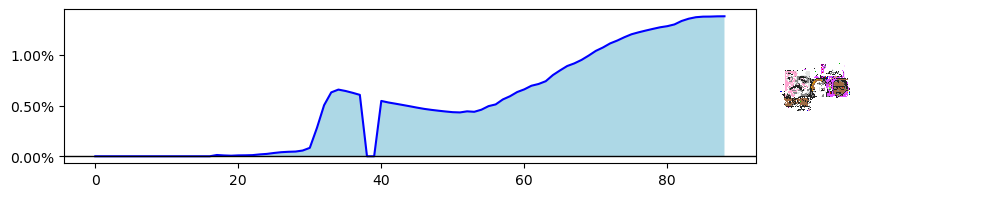

In [187]:
total, coalition_count = make_coalition_over_time(failed_dir, 30, start_time, update_user_dict)
plot_time_pos_neg(coalition_count, total_user_o_t, failed_dict[7][1],"/home/yw180/place/place_graphcut_user_emb/Merged_analysis/plots/failed_7.png")

/tmp/ipykernel_2737304/961760666.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels("count (%)")


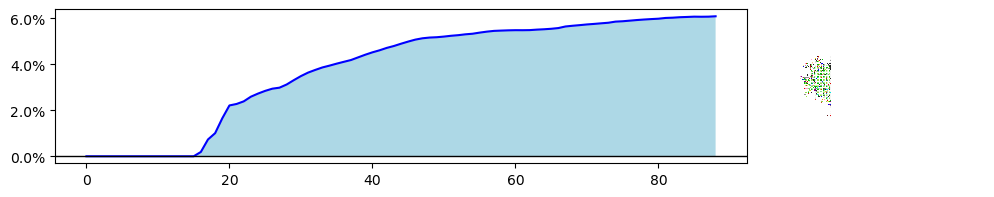

In [188]:
total, coalition_count = make_coalition_over_time(failed_dir, 2, start_time, update_user_dict)
plot_time_pos_neg(coalition_count, total_user_o_t, failed_dict[2][1],"/home/yw180/place/place_graphcut_user_emb/Merged_analysis/plots/failed_2.png")

# All successful

In [189]:
total, coalition_count = overall_coalition_over_time(successful_dir, start_time, update_user_dict)

In [191]:
def plot_time_pos_neg_no_pic(coalition_count,total_coalition,duration=89):
    fig = plt.figure(figsize=(12, 2))
#     gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.15)
#     ax = fig.add_subplot(gs[0, 0])
#     neg_x = np.arange(0, duration)
#     neg_y = np.zeros(duration)
#     total_attack = sum(attack_count.values())
#     for i in range(0, len(neg_x)):
#         if neg_x[i] in attack_count:
#             neg_y[i] = -(attack_count[neg_x[i]] / total_attack) * 100
    ax = plt.subplot(111)  

    pos_x = np.arange(0, duration)
    pos_y = np.zeros(duration)
    for i in range(0, len(pos_x)):
        if pos_x[i] in coalition_count:
            pos_y[i] = (coalition_count[pos_x[i]] / total_user_o_t[i]) * 100
    plt.plot(pos_x, pos_y, 'b-')

#     .fill_between(pos_x,0, pos_y, facecolor='#add8e6')

#     ax.plot(neg_x, neg_y, 'r-')
#     ax.fill_between(neg_x,0, neg_y, facecolor='#FFADB0')
#     ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel("count (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
#     ax.set_yticks([])
#     ax_image = fig.add_subplot(gs[0, 1])
#     img = Image.open(img_loc)
#     imgbox = OffsetImage(img, zoom=0.03)
#     ab = AnnotationBbox(imgbox, (0, 0.5), frameon=False, box_alignment=(0.5, 0.5))
#     ax_image.add_artist(ab)
#     ax_image.axis('off') 

    # Adding labels and title
#     fig.text(0.37, 0.04, 'Hours', va='center',fontsize=15)
#     fig.text(0.1, 0.5, 'Collaborative vs. Adversarial Updates', va='center', rotation='vertical',fontsize=15)

    plt.show()

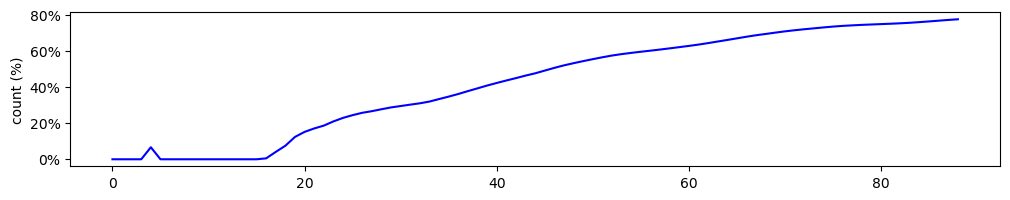

In [192]:
plot_time_pos_neg_no_pic(coalition_count, total_user_o_t)

# All failed

In [329]:
total, coalition_count = overall_coalition_over_time(failed_dir, start_time, update_user_dict)

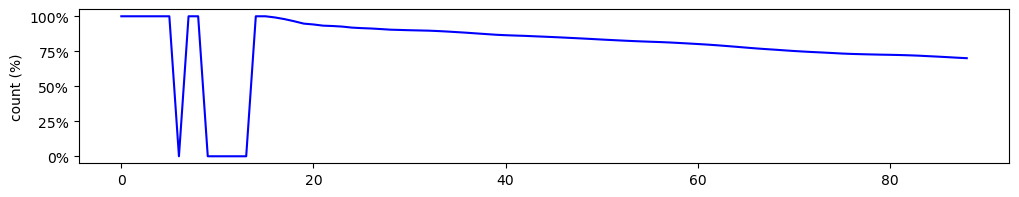

In [330]:
plot_time_pos_neg_no_pic(coalition_count, total_user_o_t)

# Coalition size at a certain time period -> distribution -> plot power law k

In [195]:
# Randomly choose 89 time stamps, one in each hour window
end_time = 1491238734

In [34]:
time_brackets = [start_time]
for i in range(0, 89):
    time_brackets.append(time_brackets[i] + 3600)

In [204]:
time_brackets[-1] = end_time

In [32]:
def calc_coalition_size_given_time(timestamp_lst, update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i,final_proj_size_dict):
    # update_user_dict has update_num: [user, time]
    power_law_alpha = list()
#     canvas = np.array(-1 * np.ones((1001, 1001)))
    max_update = max(update_user_dict.keys())
    for timestamp in sorted(timestamp_lst):
        for i in range(last_i, max_update):
            if update_user_dict[i][1] > timestamp:
                last_i = i
                break
            else:
                y,x = update_coord_dict[i]
                canvas[y,x] = i
        proj_size = dict()
        for y in range(0, 1001):
            for x in range(0, 1001):
                update = canvas[y,x]
                if update == -1:
                    continue
                proj = update_proj_dict[update]
                user = update_user_dict[update][0]
                if proj not in proj_size:
                    proj_size[proj] = {user}
                else:
                    proj_size[proj].add(user)
        out = dict()
        for key in proj_size:
            out[key] = len(proj_size[key])#/final_proj_size_dict[key]
        
        fit = powerlaw.Fit(list(out.values()))
        # Get the exponent (alpha)
        alpha = fit.power_law.alpha
        power_law_alpha.append(alpha)
    return power_law_alpha, last_i, canvas

In [334]:
import random
random_pick = list()
for i in range(1, len(time_brackets)):
    random_pick.append(random.randint(time_brackets[i - 1], time_brackets[i] - 1))

In [317]:
random_pick[80]

1491206964

In [318]:
canvas = np.array(-1 * np.ones((1001, 1001)))
last_i = 0
coalition_size_tst,last_i, canvas = calc_coalition_size_given_time([random_pick[80]],update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i,proj_size_dict)

Calculating best minimal value for power law fit


In [320]:
canvas

array([[14182274., 14072682., 13674176., ..., 14126964., 14179076.,
        14036290.],
       [14179458., 14135207., 13795652., ..., 14171049., 14124317.,
        12539508.],
       [13672837., 14174111., 14111287., ..., 14061663., 14100540.,
        12127928.],
       ...,
       [14116364., 14180243., 12871801., ..., 14182012., 14167317.,
        13784508.],
       [14172414., 14079517., 14113492., ..., 14169666., 14182568.,
        14087942.],
       [13835387., 13586940., 12943479., ..., 13456125., 14124532.,
        14180201.]])

Text(0, 0.5, 'frequency')

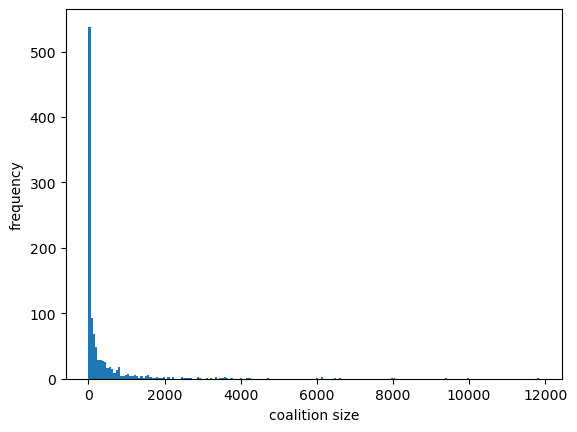

In [256]:
plt.hist(coalition_size_tst.values(), bins='auto')
plt.xlabel("coalition size")
plt.ylabel("frequency")


In [252]:
fit = powerlaw.Fit(list(coalition_size_tst.values()))

# Get the exponent (alpha)
alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

print(f"Estimated alpha: {alpha:.3f}")
print(f"Estimated xmin: {xmin}")

Calculating best minimal value for power law fit
Estimated alpha: 2.248
Estimated xmin: 671.0


In [239]:
update_user_dict[48]

['/Xps73KHIk/Nq/0bTtoLOSl6a0g=', 1490922503]

In [326]:
canvas = np.array(-1 * np.ones((1001, 1001)))
last_i = 0
power_law_alpha,last_i, canvas = calc_coalition_size_given_time(random_pick,update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i, proj_size_dict)

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best min

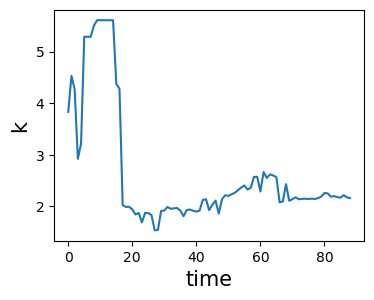

In [328]:
pos_x = np.arange(0, len(random_pick))
plt.figure(figsize=(4,3))
ax = plt.subplot(111)

plt.plot(pos_x, power_law_alpha)
ax.set_ylabel('k', fontsize=15)
ax.set_xlabel('time', fontsize=15)
ax.tick_params(labelsize=10)

# Randomly pick 5 within each hour

In [38]:
import random
random_pick = list()
for i in range(1, len(time_brackets)):
    random_pick.append(random.sample(range(time_brackets[i - 1],time_brackets[i]), 5))

In [272]:
out = calc_coalition_size_given_time(random_pick[0][6],update_user_dict, update_coord_dict,update_proj_dict)
fit = powerlaw.Fit(list(out.values()))

# Get the exponent (alpha)
alpha = fit.power_law.alpha

Calculating best minimal value for power law fit


In [40]:
power_law_alpha = list()
canvas = np.array(-1 * np.ones((1001, 1001)))
last_i = 0
for i in range(0, len(random_pick)):
    lst = random_pick[i]
    curr_list = list()
    # def calc_coalition_size_given_time(timestamp_lst, update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i):

    out, last_i, canvas = calc_coalition_size_given_time(lst,update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i, final_proj_size_dict=proj_size_dict)
    power_law_alpha.append(np.mean(np.array(out)))

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best min

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best min

In [46]:
def calc_coalition_size_given_time_dist(timestamp, update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i,final_proj_size_dict):
    # update_user_dict has update_num: [user, time]
    power_law_alpha = list()
#     canvas = np.array(-1 * np.ones((1001, 1001)))
    max_update = max(update_user_dict.keys())
    for i in range(last_i, max_update):
        if update_user_dict[i][1] > timestamp:
            last_i = i
            break
        else:
            y,x = update_coord_dict[i]
            canvas[y,x] = i
    proj_size = dict()
    for y in range(0, 1001):
        for x in range(0, 1001):
            update = canvas[y,x]
            if update == -1:
                continue
            proj = update_proj_dict[update]
            user = update_user_dict[update][0]
            if proj not in proj_size:
                proj_size[proj] = {user}
            else:
                proj_size[proj].add(user)
    out = dict()
    for key in proj_size:
        out[key] = len(proj_size[key])
    return out, last_i, canvas

In [167]:
# Distribution in hour 24, 48, 72
time_1 = random_pick[15][1]
time_2 = random_pick[40][0]
time_3 = random_pick[72][0]
canvas = np.array(-1 * np.ones((1001, 1001)))
last_i = 0
dist_1, last_i, canvas = calc_coalition_size_given_time_dist(time_1,update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i, final_proj_size_dict=proj_size_dict)
dist_2, last_i, canvas = calc_coalition_size_given_time_dist(time_2,update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i, final_proj_size_dict=proj_size_dict)
dist_3, last_i, canvas = calc_coalition_size_given_time_dist(time_3,update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i, final_proj_size_dict=proj_size_dict)

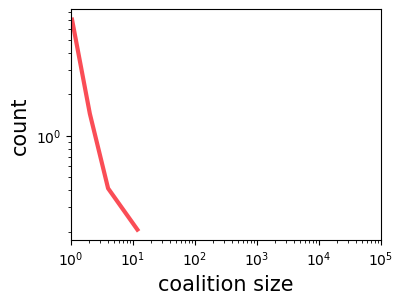

In [162]:
counts, bin_edges = np.histogram(np.array(list(dist_1.values()),dtype=np.float64), bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

mask = counts > 0
bin_centers = bin_centers[mask]
counts = counts[mask]
# Plot as line
plt.figure(figsize=(4,3))
ax = plt.subplot(111)
ax.plot(bin_centers, counts, linewidth=3,color='#fa4d56')
# plt.hist(dist_3.values(), bins='auto')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("coalition size", fontsize=15)
ax.set_ylabel("count", fontsize=15)
ax.set_xlim(1, 10**5)

plt.savefig("dist_1.png")

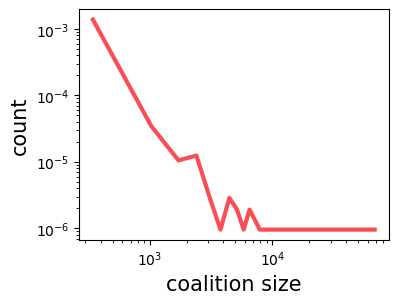

In [163]:
counts, bin_edges = np.histogram(np.array(list(dist_2.values()),dtype=np.float64), bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

mask = counts > 0
bin_centers = bin_centers[mask]
counts = counts[mask]
# Plot as line
plt.figure(figsize=(4,3))
ax = plt.subplot(111)
ax.plot(bin_centers, counts, color='#fa4d56', linewidth=3)
# plt.hist(dist_3.values(), bins='auto')
# ax.set_xlim(1, 10**5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("coalition size", fontsize=15)
ax.set_ylabel("count", fontsize=15)
plt.savefig("dist_2.png")

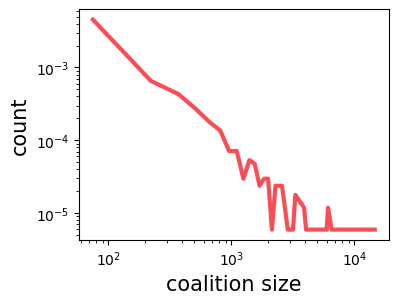

In [168]:
counts, bin_edges = np.histogram(np.array(list(dist_3.values()),dtype=np.float64), bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

mask = counts > 0
bin_centers = bin_centers[mask]
counts = counts[mask]
# Plot as line
plt.figure(figsize=(4,3))
ax = plt.subplot(111)
ax.plot(bin_centers, counts, color='#fa4d56', linewidth=3)
# plt.hist(dist_3.values(), bins='auto')
# ax.set_xlim(1, 10**5)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("coalition size", fontsize=15)
ax.set_ylabel("count", fontsize=15)
plt.savefig("dist_3.png")

In [126]:
counts

array([4.53902287e-03, 6.50968078e-04, 4.32006088e-04, 2.66305123e-04,
       1.77536749e-04, 1.36111507e-04, 7.10146995e-05, 7.10146995e-05,
       2.95894581e-05, 5.32610246e-05, 4.73431330e-05, 2.36715665e-05,
       2.95894581e-05, 2.95894581e-05, 5.91789162e-06, 2.36715665e-05,
       2.36715665e-05, 2.36715665e-05, 1.18357832e-05, 5.91789162e-06,
       5.91789162e-06, 5.91789162e-06, 1.77536749e-05, 1.18357832e-05,
       5.91789162e-06, 5.91789162e-06, 5.91789162e-06, 5.91789162e-06,
       5.91789162e-06, 1.18357832e-05, 5.91789162e-06, 5.91789162e-06,
       5.91789162e-06, 5.91789162e-06, 5.91789162e-06, 5.91789162e-06,
       5.91789162e-06])

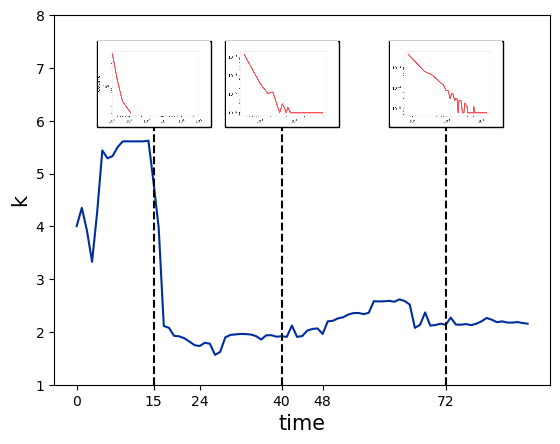

In [171]:
zoom = 0.2
up_line=6.7
pos_x = np.arange(0, len(random_pick))
# plt.figure(figsize=(6,5))

ax = plt.subplot(111)

plt.plot(pos_x, power_law_alpha,color="#002d9c")
ax.set_ylabel('k', fontsize=15)
ax.set_xlabel('time', fontsize=15)

arr_img = plt.imread("dist_1.png", format='png')
imagebox = OffsetImage(arr_img, zoom=zoom)
imagebox.image.axes = ax
ab = AnnotationBbox(imagebox, (15, up_line),
                None,
                xycoords='data',
                pad=0.1)
ax.add_artist(ab)

arr_img = plt.imread("dist_2.png", format='png')
imagebox = OffsetImage(arr_img, zoom=zoom)
imagebox.image.axes = ax
ab = AnnotationBbox(imagebox, (40, up_line),
                None,
                xycoords='data',
                pad=0.1)
ax.add_artist(ab)

arr_img = plt.imread("dist_3.png", format='png')
imagebox = OffsetImage(arr_img, zoom=zoom)
imagebox.image.axes = ax
ab = AnnotationBbox(imagebox, (72, up_line),
                None,
                xycoords='data',
                pad=0.1)
ax.add_artist(ab)

ax.set_xticks([0,15,24,40,48,72])

ax.set_ylim(1, 8)
ax.vlines([15,40,72],ymin=1,ymax=up_line,color='k', linestyle='--')

ax.tick_params(labelsize=10)

In [140]:
power_law_alpha[15:24]

[4.830126222632852,
 3.973900197117419,
 2.1119087316357272,
 2.077940102701879,
 1.9264669455603898,
 1.9161973931140195,
 1.8809624030735008,
 1.8165337722431842,
 1.749171457595152]

# Size so far

In [180]:
def calc_coalition_size_given_time_cumulative(timestamp_lst, update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i,final_proj_size_dict,proj_user):
    # update_user_dict has update_num: [user, time]
    power_law_alpha = list()
#     canvas = np.array(-1 * np.ones((1001, 1001)))
    max_update = max(update_user_dict.keys())
    for timestamp in sorted(timestamp_lst):
        for i in range(last_i, max_update):
            if update_user_dict[i][1] > timestamp:
                last_i = i
                break
            else:
                if i not in update_proj_dict:
                    continue
                proj = update_proj_dict[i]
                user = update_user_dict[i][0]
#                 print(proj, user)
                if proj not in proj_user:
                    proj_user[proj] = {user}
                else:
                    proj_user[proj].add(user)
                y,x = update_coord_dict[i]
                canvas[y,x] = i
        proj_keys_on_canvas = set()
        for y in range(0, 1001):
            for x in range(0, 1001):
                update = canvas[y,x]
                if update == -1:
                    continue
                proj = update_proj_dict[update]
                proj_keys_on_canvas.add(proj)
        out = dict()
        total = 0
        for key in proj_keys_on_canvas:
            out[key] = len(proj_user[key])#/final_proj_size_dict[key]
            total += out[key]
        fit = powerlaw.Fit(np.array(list(out.values())) / total)
        # Get the exponent (alpha)
        alpha = fit.power_law.alpha
        power_law_alpha.append(alpha)
    return power_law_alpha, last_i, canvas, proj_user

In [ ]:
power_law_alpha = list()
canvas = np.array(-1 * np.ones((1001, 1001)))
last_i = 0
proj_user = dict()

for i in range(0, len(random_pick)):
    lst = random_pick[i]
    curr_list = list()
    # def calc_coalition_size_given_time(timestamp_lst, update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i):

    out, last_i, canvas, proj_user = calc_coalition_size_given_time_cumulative(lst,update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i, proj_size_dict, proj_user)
    power_law_alpha.append(np.mean(np.array(out)))


In [181]:
random_pick[80]

[1491209956, 1491210213, 1491206920, 1491208245, 1491209049]

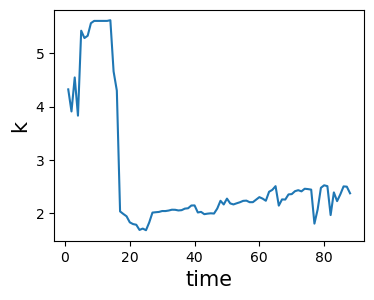

In [184]:
pos_x = np.arange(0, len(random_pick))
plt.figure(figsize=(4,3))
ax = plt.subplot(111)

plt.plot(pos_x, power_law_alpha)
ax.set_ylabel('k', fontsize=15)
ax.set_xlabel('time', fontsize=15)
ax.tick_params(labelsize=10)

In [203]:
def calc_coalition_size_given_time_cumulative_dist(timestamp, update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i,final_proj_size_dict,proj_user):
    # update_user_dict has update_num: [user, time]
    power_law_alpha = list()
#     canvas = np.array(-1 * np.ones((1001, 1001)))
    max_update = max(update_user_dict.keys())
    for i in range(last_i, max_update):
        if update_user_dict[i][1] > timestamp:
            last_i = i
            break
        else:
            if i not in update_proj_dict:
                continue
            proj = update_proj_dict[i]
            user = update_user_dict[i][0]
#                 print(proj, user)
            if proj not in proj_user:
                proj_user[proj] = {user}
            else:
                proj_user[proj].add(user)
            y,x = update_coord_dict[i]
            canvas[y,x] = i
    proj_keys_on_canvas = set()
    for y in range(0, 1001):
        for x in range(0, 1001):
            update = canvas[y,x]
            if update == -1:
                continue
            proj = update_proj_dict[update]
            proj_keys_on_canvas.add(proj)
    out = dict()
    total = 0
    max_size = 0
    for key in proj_keys_on_canvas:
        out[key] = len(proj_user[key])#/final_proj_size_dict[key]
        total += out[key]
        if max_size < out[key]:
            max_size = out[key]
    print("max size:", max_size)
    print("total: ", total)
    out = np.array(list(out.values()))/total
    return out, last_i, canvas, proj_user

In [204]:
power_law_alpha = list()
canvas = np.array(-1 * np.ones((1001, 1001)))
last_i = 0
proj_user = dict()

time_1 = random_pick[24][0]
time_2 = random_pick[48][0]
time_3 = random_pick[72][0]
dist_1, last_i, canvas, proj_user = calc_coalition_size_given_time_cumulative_dist(time_1,update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i, proj_size_dict, proj_user)
dist_2, last_i, canvas, proj_user = calc_coalition_size_given_time_cumulative_dist(time_2,update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i, proj_size_dict, proj_user)
dist_3, last_i, canvas, proj_user = calc_coalition_size_given_time_cumulative_dist(time_3,update_user_dict, update_coord_dict,update_proj_dict, canvas, last_i, proj_size_dict, proj_user)


max size: 114496
total:  520578
max size: 169912
total:  1675470
max size: 178762
total:  3070993


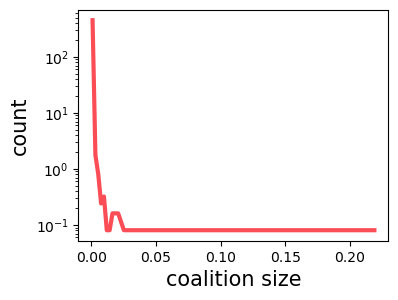

In [227]:
counts_1, bin_edges_1 = np.histogram(dist_1, bins=100, density=True)
bin_centers_1 = (bin_edges_1[:-1] + bin_edges_1[1:]) / 2

mask = counts_1 > 0
bin_centers_1 = bin_centers_1[mask]
counts_1 = counts_1[mask]
# Plot as line
plt.figure(figsize=(4,3))
ax = plt.subplot(111)
ax.plot(bin_centers_1, counts_1, linewidth=3,color='#fa4d56')

# ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("coalition size", fontsize=15)
ax.set_ylabel("count", fontsize=15)
# ax.set_xlim(0, 1)

plt.savefig("dist_1.png")

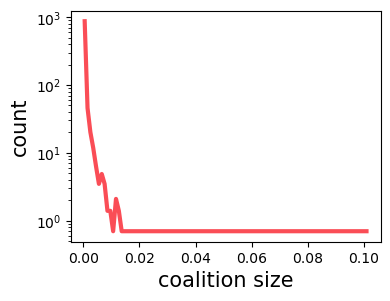

In [228]:
counts_2, bin_edges_2 = np.histogram(dist_2, bins=100, density=True)
bin_centers_2 = (bin_edges_2[:-1] + bin_edges_2[1:]) / 2

mask = counts_2 > 0
bin_centers_2 = bin_centers_2[mask]
counts_2 = counts_2[mask]
# Plot as line
plt.figure(figsize=(4,3))
ax = plt.subplot(111)
ax.plot(bin_centers_2, counts_2, linewidth=3,color='#fa4d56')
# plt.hist(dist_3.values(), bins='auto')

# ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("coalition size", fontsize=15)
ax.set_ylabel("count", fontsize=15)
# ax.set_xlim(0, 1)

plt.savefig("dist_2.png")

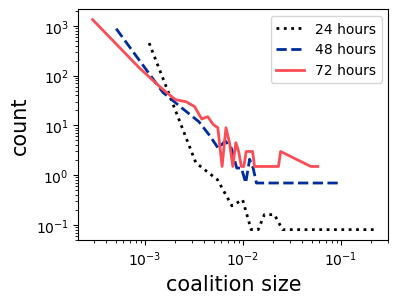

In [253]:
counts_3, bin_edges_3 = np.histogram(dist_3, bins=100, density=True)
bin_centers_3 = (bin_edges_3[:-1] + bin_edges_3[1:]) / 2

mask = counts_3 > 0
bin_centers_3 = bin_centers_3[mask]
counts_3 = counts_3[mask]
# Plot as line
plt.figure(figsize=(4,3))
ax = plt.subplot(111)
ax.plot(bin_centers_1, counts_1, linewidth=2,color="k", linestyle=':', markevery=0.1,label='24 hours')

ax.plot(bin_centers_2, counts_2, linewidth=2,color="#002d9c", linestyle='--', markevery = 0.1, label = '48 hours')

ax.plot(bin_centers_3, counts_3, linewidth=2,color='#fa4d56', linestyle='-',label = '72 hours')

ax.legend(loc='upper right')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("coalition size", fontsize=15)
ax.set_ylabel("count", fontsize=15)
# ax.set_xlim(0, 1)

plt.savefig("dist_3.png")